In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#import seaborn as sns
import sklearn

In [3]:
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.feature_selection import f_regression

In [4]:
from vaccination_functions import *
from acs_data_functions import *

In [5]:
tx_mmr_vac_rates = pd.read_csv("../TX_MMR_vax_rate_24_25.csv")
tx_mmr_vac_rates.head()

,Facility Number,School Type,School District or Name,Facility Address,County,MMR Vaccination Rate,Age Group
0,9057829000,Public School,A+ ACADEMY,"8225 BRUTON RD, DALLAS, TX, .",Dallas,96.77,Kindergarten
1,9109901000,Public School,ABBOTT ISD,"P O BOX 226, ABBOTT, TX, .",Hill,95.24,Kindergarten
2,9095901000,Public School,ABERNATHY ISD,"505 7TH ST, ABERNATHY, TX, .",Hale,93.22,Kindergarten
3,9221901000,Public School,ABILENE ISD,"P O BOX 981, ABILENE, TX, .",Taylor,97.76,Kindergarten
4,9014901000,Public School,ACADEMY ISD,"704 E MAIN ST, LITTLE RIVER, TX, .",Bell,98.04,Kindergarten


In [6]:
counties_with_vac = tx_mmr_vac_rates['County'].unique()
#tx_mmr_vac_rates['County'].unique()

In [7]:
acs_data_path = "../acs_data/"

age_df = pd.read_csv(acs_data_path+"tx_county_agePop_24.csv")
age_var_df = pd.read_csv(acs_data_path+"ageVars_acs.csv")

race_df = pd.read_csv(acs_data_path+"tx_county_racePop_24.csv")
race_var_df = pd.read_csv(acs_data_path+"raceVars_acs.csv")

education_df = pd.read_csv(acs_data_path+"tx_county_education_24.csv")
education_var_df = pd.read_csv(acs_data_path+"educationVars_acs.csv")

#enrollment_df = pd.read_csv(acs_data_path+"tx_county_enrollment_24.csv")
#enrollment_var_df = pd.read_csv(acs_data_path+"enrollmentVars_acs.csv")

enrollment_ext_df = pd.read_csv(acs_data_path+"tx_county_enrollment_24_extended.csv")
enrollment_var_ext_df = pd.read_csv(acs_data_path+"enrollmentVars_acs_extended.csv")

poverty_df = pd.read_csv(acs_data_path+"tx_county_poverty_24.csv")
poverty_var_df = pd.read_csv(acs_data_path+"povertyVars_acs.csv")


In [8]:
enroll_concepts = ['B14001_', 'B14002_', 'B14003_', 'B14006_', 'B14007', 'B14007_', 'B14007A_', 'B14007B_', 'B14007C_',
                   'B14007D_', 'B14007E_', 'B14007F_', 'B14007G_', 'B14007H_', 'B14007I_',]
enroll_df_dict = {}
for c in enroll_concepts:
    enroll_sub_df = enrollment_ext_df[enrollment_ext_df['variable'].str.contains(c)]
    enroll_df_dict[c] = enroll_sub_df

In [9]:
enroll_totals_df = enroll_df_dict['B14001_']
enroll_gender_grade_df = enroll_df_dict['B14002_']
enroll_gender_type_age_df = enroll_df_dict['B14003_']
enroll_poverty_df = enroll_df_dict['B14006_']
enroll_detailed_grade_race_df = enroll_df_dict['B14007']
#enroll_detailed_grade_all_df = enroll_df_dict['B14007A_']
#enroll_detailed_grade_all_df = enroll_df_dict['B14007B_']
#enroll_detailed_grade_all_df = enroll_df_dict['B14007C_']

#enroll_total_df = enroll_df_dict['B14001_']

In [10]:
age_with_var_all, age_with_var_no_gender = create_predictor_datasets(age_df, age_var_df, counties_with_vac)
race_with_var_all, race_with_var_no_gender = create_predictor_datasets(race_df, race_var_df, counties_with_vac)
education_with_var_all, education_with_var_no_gender = create_predictor_datasets(education_df, education_var_df, counties_with_vac)
#enrollment_with_var_all, enrollment_with_var_no_gender = create_predictor_datasets(enrollment_df, enrollment_var_df, counties_with_vac)
#enrollment_ext_with_var_all, enrollment_ext_with_var_no_gender = create_predictor_datasets(enrollment_ext_df, enrollment_var_ext_df, counties_with_vac)
poverty_with_var_all, poverty_with_var_no_gender = create_predictor_datasets(poverty_df, poverty_var_df, counties_with_vac)

In [24]:
enrollment_gender_grade_with_var_all, enrollment_gender_grade_with_var_no_gender = create_predictor_datasets(enroll_gender_grade_df, enrollment_var_ext_df, counties_with_vac)
enrollment_totals_with_var_all, enrollment_totals_with_var_no_gender = create_predictor_datasets(enroll_totals_df, enrollment_var_ext_df, counties_with_vac)
enrollment_gender_type_with_var_all, enrollment_gender_type_with_var_no_gender = create_predictor_datasets(enroll_gender_type_age_df, enrollment_var_ext_df, counties_with_vac)
enrollment_poverty_with_var_all, enrollment_poverty_with_var_no_gender = create_predictor_datasets(enroll_poverty_df, enrollment_var_ext_df, counties_with_vac)
enrollment_grade_race_with_var_all, enrollment_grade_race_with_var_no_gender = create_predictor_datasets(enroll_detailed_grade_race_df, enrollment_var_ext_df, counties_with_vac)

In [27]:
enrollment_totals_with_var_all.columns = enrollment_totals_with_var_all.columns.str.replace({'_School_Enrollment_by_Level_of_School_for_the_Population_': '_School_Enrollment_'}, regex=True)
enrollment_gender_grade_with_var_all.columns = enrollment_gender_grade_with_var_all.columns.str.replace({'_Sex_by_School_Enrollment_by_Level_of_School_by_Type_of_School_for_the_Population_': '_School_Enrollment_'}, regex=True)
enrollment_gender_type_with_var_all.columns = enrollment_gender_type_with_var_all.columns.str.replace({'_Sex_by_School_Enrollment_by_Type_of_School_by_Age_for_the_Population_': '_School_Enrollment_'}, regex=True)
enrollment_poverty_with_var_all.columns = enrollment_poverty_with_var_all.columns.str.replace({'_in_the_Past_12_Months_by_School_Enrollment_by_Level_of_School_for_the_Population_': '_School_Enrollment_'}, regex=True)
enrollment_grade_race_with_var_all.columns = enrollment_grade_race_with_var_all.columns.str.replace({'_by_Detailed_Level_of_School_for_the_Population_': '_'}, regex=True)

In [9]:
age_with_var_no_gender['Estimate_Total_Under_5'] = age_with_var_all['Estimate_Total_Male_Under_5'] + age_with_var_all['Estimate_Total_Female_Under_5']
age_with_var_no_gender['Estimate_Total_5_9'] = age_with_var_all['Estimate_Total_Male_5_9'] + age_with_var_all['Estimate_Total_Female_5_9']
age_with_var_no_gender['Estimate_Total_10_14'] = age_with_var_all['Estimate_Total_Male_10_14'] + age_with_var_all['Estimate_Total_Female_10_14']
age_with_var_no_gender['Estimate_Total_15_17'] = age_with_var_all['Estimate_Total_Male_15_17'] + age_with_var_all['Estimate_Total_Female_15_17']
age_with_var_no_gender['Estimate_Total_18_19'] = age_with_var_all['Estimate_Total_Male_18_and_19'] + age_with_var_all['Estimate_Total_Female_18_and_19']
age_with_var_no_gender['Estimate_Total_21'] = age_with_var_all['Estimate_Total_Male_21'] + age_with_var_all['Estimate_Total_Female_21']
age_with_var_no_gender['Estimate_Total_22_24'] = age_with_var_all['Estimate_Total_Male_22_24'] + age_with_var_all['Estimate_Total_Female_22_24']
age_with_var_no_gender['Estimate_Total_25_29'] = age_with_var_all['Estimate_Total_Male_25_29'] + age_with_var_all['Estimate_Total_Female_25_29']
age_with_var_no_gender['Estimate_Total_30_34'] = age_with_var_all['Estimate_Total_Male_30_34'] + age_with_var_all['Estimate_Total_Female_30_34']
age_with_var_no_gender['Estimate_Total_35_39'] = age_with_var_all['Estimate_Total_Male_35_39'] + age_with_var_all['Estimate_Total_Female_35_39']


KeyError: 'Estimate_Total_Male_Under_5'

In [25]:
age_with_var_no_gender['Estimate_Total_40_44'] = age_with_var_all['Estimate_Total_Male_40_44'] + age_with_var_all['Estimate_Total_Female_40_44']
age_with_var_no_gender['Estimate_Total_45_49'] = age_with_var_all['Estimate_Total_Male_45_49'] + age_with_var_all['Estimate_Total_Female_45_49']
age_with_var_no_gender['Estimate_Total_50_54'] = age_with_var_all['Estimate_Total_Male_50_54'] + age_with_var_all['Estimate_Total_Female_50_54']
age_with_var_no_gender['Estimate_Total_55_59'] = age_with_var_all['Estimate_Total_Male_55_59'] + age_with_var_all['Estimate_Total_Female_55_59']
age_with_var_no_gender['Estimate_Total_60_61'] = age_with_var_all['Estimate_Total_Male_60_and_61'] + age_with_var_all['Estimate_Total_Female_60_and_61']
age_with_var_no_gender['Estimate_Total_62_64'] = age_with_var_all['Estimate_Total_Male_62_64'] + age_with_var_all['Estimate_Total_Female_62_64']
age_with_var_no_gender['Estimate_Total_65_66'] = age_with_var_all['Estimate_Total_Male_65_and_66'] + age_with_var_all['Estimate_Total_Female_65_and_66']
age_with_var_no_gender['Estimate_Total_67_69'] = age_with_var_all['Estimate_Total_Male_67_69'] + age_with_var_all['Estimate_Total_Female_67_69']
age_with_var_no_gender['Estimate_Total_70_74'] = age_with_var_all['Estimate_Total_Male_70_74'] + age_with_var_all['Estimate_Total_Female_70_74']
age_with_var_no_gender['Estimate_Total_75_79'] = age_with_var_all['Estimate_Total_Male_75_79'] + age_with_var_all['Estimate_Total_Female_75_79']
age_with_var_no_gender['Estimate_Total_80_84'] = age_with_var_all['Estimate_Total_Male_80_84'] + age_with_var_all['Estimate_Total_Female_80_84']
age_with_var_no_gender['Estimate_Total_85_over'] = age_with_var_all['Estimate_Total_Male_85_and_over'] + age_with_var_all['Estimate_Total_Female_85_and_over']

In [ ]:
#age_with_var_all_percent, age_with_var_no_gender_percent = create_predictor_percentages(age_with_var_all, age_with_var_no_gender)
#race_with_var_all_percent, race_with_var_no_gender_percent = create_predictor_percentages(race_with_var_all, race_with_var_no_gender)
#education_with_var_all_percent, education_with_var_no_gender_percent = create_predictor_percentages(education_with_var_all, education_with_var_no_gender)
#enrollment_with_var_all_percent, enrollment_with_var_no_gender_percent = create_predictor_percentages(enrollment_with_var_all, enrollment_with_var_no_gender)

KeyError: "['Estimate_Total'] not found in axis"

In [ ]:
### Predictor datasets with vaccination rates for absolute values
#race_vac_set_all = vac_predictor_merge(tx_mmr_vac_rates, race_with_var_all)
#race_vac_set_no_gender = vac_predictor_merge(tx_mmr_vac_rates, race_with_var_no_gender)
#age_vac_set_all = vac_predictor_merge(tx_mmr_vac_rates, age_with_var_all)
# age_vac_set_no_gender = vac_predictor_merge(tx_mmr_vac_rates, age_with_var_no_gender)
#education_vac_set_all =  vac_predictor_merge(tx_mmr_vac_rates, education_with_var_all)
#education_vac_set_no_gender = vac_predictor_merge(tx_mmr_vac_rates, education_with_var_no_gender)
#enrollment_vac_set_all = vac_predictor_merge(tx_mmr_vac_rates, enrollment_with_var_all)
# enrollment_vac_set_no_gender = vac_predictor_merge(tx_mmr_vac_rates, enrollment_with_var_no_gender)
#poverty_vac_set_all = vac_predictor_merge(tx_mmr_vac_rates, poverty_with_var_all)


#poverty_vac_set_all.head()

In [14]:
### Predictor datasets with vaccination rates for percentages
race_vac_set_all_percent, race_vac_set_no_gender_percent = vac_predictor_merge(tx_mmr_vac_rates, race_with_var_all_percent, race_with_var_no_gender_percent)
age_vac_set_all, age_vac_set_no_gender_percent = vac_predictor_merge(tx_mmr_vac_rates, age_with_var_all_percent, age_with_var_no_gender_percent)
education_vac_set_all_percent, education_vac_set_no_gender_percent = vac_predictor_merge(tx_mmr_vac_rates, education_with_var_all_percent, education_with_var_no_gender_percent)
#enrollment_vac_set_all_percent, enrollment_vac_set_no_gender_percent = vac_predictor_merge(tx_mmr_vac_rates, enrollment_with_var_all_percent, enrollment_with_var_no_gender_percent)
enrollment_ext_vac_set_all_percent, enrollment_ext_vac_set_no_gender_percent = vac_predictor_merge(tx_mmr_vac_rates, enrollment_ext_with_var_all_percent, enrollment_ext_with_var_no_gender_percent)

In [21]:
#### Linear Regression

In [22]:
#eudcation_intercept, education_results_df, education_fit_summary = linear_regression_fit(education_vac_set_no_gender.drop(columns=['B15003_025']))
#eudcation_intercept, education_results_df = linear_regression_fit(education_vac_set_no_gender.drop(columns=['B15003_025']), predictor_name='education_variables', sort_and_save=True)
#education_results_df

In [23]:
#eudcation_intercept_percent, education_results_df_percent = linear_regression_fit(education_vac_set_no_gender_percent.drop(columns=['B15003_025']))
#eudcation_intercept_percent, education_results_df_percent, education_percent_fit_summary = linear_regression_fit(education_vac_set_no_gender_percent.drop(columns=['B15003_025']), predictor_name='education_variables_percent', sort_and_save=True)
#eudcation_intercept_percent, education_results_df_percent, education_percent_fit_summary = linear_regression_fit(education_vac_set_no_gender_percent.drop(columns=['B15003_025']), predictor_name='education_variables_percent')
#education_results_df_percent

In [24]:
#race_intercept, race_results_df, race_fit_summary = linear_regression_fit(race_vac_set_no_gender)
#race_intercept, race_results_df = linear_regression_fit(race_vac_set_no_gender, predictor_name='race_variables', sort_and_save=True)
#race_results_df

In [25]:
#race_intercept_percent, race_results_df_percent = linear_regression_fit(race_vac_set_no_gender_percent)
#race_intercept_percent, race_results_df_percent, race_percent_fit_summary = linear_regression_fit(race_vac_set_no_gender_percent, predictor_name='race_variables_percent', sort_and_save=True)
#race_intercept_percent, race_results_df_percent, race_percent_fit_summary = linear_regression_fit(race_vac_set_no_gender_percent, predictor_name='race_variables_percent')
#race_results_df_percent

In [26]:
#enrollment_intercept, enrollment_results_df, enrollment_fit_summary = linear_regression_fit(enrollment_vac_set_no_gender)
#enrollment_intercept_percent, enrollment_results_df_percent = linear_regression_fit(enrollment_vac_set_no_gender, predictor_name='enrollment_variables', sort_and_save=True)
#enrollment_results_df

In [27]:
#enrollment_intercept_percent, enrollment_results_df_percent = linear_regression_fit(enrollment_vac_set_no_gender_percent)
#enrollment_intercept_percent, enrollment_results_df_percent, enrollment_percent_fit_summary = linear_regression_fit(enrollment_vac_set_no_gender_percent, predictor_name='enrollment_variables_percent', sort_and_save=True)
#enrollment_intercept_percent, enrollment_results_df_percent, enrollment_percent_fit_summary = linear_regression_fit(enrollment_vac_set_no_gender_percent, predictor_name='enrollment_variables_percent')
#enrollment_results_df_percent

In [28]:
#age_intercept, age_results_df, age_fit_summary = linear_regression_fit(age_vac_set_no_gender)
#age_intercept, age_results_df = linear_regression_fit(age_vac_set_no_gender, predictor_name='age_variables', sort_and_save=True)
#age_results_df

In [29]:
#age_intercept_percent, age_results_df_percent = linear_regression_fit(age_vac_set_no_gender_percent)
#age_intercept_percent, age_results_df_percent, age_percent_fit_summary = linear_regression_fit(age_vac_set_no_gender_percent, predictor_name='age_variables_percent', sort_and_save=True)
#age_intercept_percent, age_results_df_percent, age_percent_fit_summary = linear_regression_fit(age_vac_set_no_gender_percent, predictor_name='age_variables_percent')
#age_results_df_percent

In [30]:
#poverty_intercept, poverty_results_df = linear_regression_fit(poverty_vac_set_all, predictor_name='poverty_variables', sort_and_save=True)
#poverty_intercept, poverty_results_df, poverty_fit_summary = linear_regression_fit(poverty_vac_set_all)
#poverty_results_df

In [31]:
#results_array = [poverty_results_df, age_results_df, race_results_df, enrollment_results_df, education_results_df]
#results_array_percent = [poverty_results_df, age_results_df_percent, race_results_df_percent, enrollment_results_df_percent, education_results_df_percent]

In [ ]:
#all_acs_variables_no_gender = combine_all_acs_variables(education_with_var_no_gender, race_with_var_no_gender, enrollment_with_var_no_gender, age_with_var_no_gender, poverty_with_var_all)
#all_acs_variables_all = combine_all_acs_variables(education_with_var_all, race_with_var_all, enrollment_with_var_all, age_with_var_all, poverty_with_var_all)

In [ ]:
#all_vac_set = vac_predictor_merge(tx_mmr_vac_rates, all_acs_variables_all)
#all_vac_set_no_gender = vac_predictor_merge(tx_mmr_vac_rates, all_acs_variables_no_gender)
#all_vac_set
#all_vac_set_no_gender

,County,Estimate_Total_10th_grade,Estimate_Total_11th_grade,"Estimate_Total_12th_grade,_no_diploma",Estimate_Total_1st_grade,Estimate_Total_2nd_grade,Estimate_Total_3rd_grade,Estimate_Total_4th_grade,Estimate_Total_5th_grade,Estimate_Total_6th_grade,...,Estimate_Total_62_64,Estimate_Total_65_66,Estimate_Total_67_69,Estimate_Total_70_74,Estimate_Total_75_79,Estimate_Total_80_84,Estimate_Total_85_over,Estimate_Total_Income_in_the_past_12_months_at_or_above_the_poverty_level_Did_not_work,Estimate_Total_Income_in_the_past_12_months_below_the_poverty_level,MMR Vaccination Rate
0,Anderson,1235,1008,1386,15,51,32,57,81,202,...,1746,1224,1802,2319,1643,1369,508,2137,2492,90.24
1,Anderson,1235,1008,1386,15,51,32,57,81,202,...,1746,1224,1802,2319,1643,1369,508,2137,2492,93.00
2,Anderson,1235,1008,1386,15,51,32,57,81,202,...,1746,1224,1802,2319,1643,1369,508,2137,2492,96.23
3,Anderson,1235,1008,1386,15,51,32,57,81,202,...,1746,1224,1802,2319,1643,1369,508,2137,2492,93.75
4,Anderson,1235,1008,1386,15,51,32,57,81,202,...,1746,1224,1802,2319,1643,1369,508,2137,2492,96.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3077,Zapata,670,179,195,0,28,94,56,71,113,...,315,244,437,381,320,233,335,396,913,100.00
3078,Zavala,132,228,235,0,3,18,128,0,77,...,93,146,289,503,219,72,248,92,784,100.00
3079,Zavala,132,228,235,0,3,18,128,0,77,...,93,146,289,503,219,72,248,92,784,100.00
3080,Zavala,132,228,235,0,3,18,128,0,77,...,93,146,289,503,219,72,248,92,784,100.00


In [34]:
#all_intercept, all_results_df, all_summary = linear_regression_fit(all_vac_set, predictor_name='comb_acs_variables', sort_and_save=True)
#all_intercept, all_results_df, all_summary = linear_regression_fit(all_vac_set, predictor_name='comb_acs_variables')
#all_results_df

In [ ]:
all_acs_variables_percent = combine_all_acs_variables(education_with_var_all_percent, race_with_var_all_percent, enrollment_with_var_all_percent, age_with_var_all_percent, poverty_with_var_all, percent=True, gender=True)
all_acs_variables_no_gender_percent = combine_all_acs_variables(education_with_var_no_gender_percent, race_with_var_no_gender_percent, enrollment_with_var_no_gender_percent, age_with_var_no_gender_percent, poverty_with_var_all, percent=True)

c:\Users\19037\Documents\Measels_Vaccination\code_backup\acs_data_functions.py:105: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  edu_race_df = pd.merge(edu_df.drop(columns=['Estimate_Total', 'B15003_025', 'Percent_Male', 'Percent_Female']), race_df.drop(columns=['Estimate_Total']), on=['County'])
c:\Users\19037\Documents\Measels_Vaccination\code_backup\acs_data_functions.py:107: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_acs_variables = pd.merge(pd.merge(edu_race_df, enroll_age_df, on=['County']), poverty_df, on=['County

In [ ]:
all_vac_set_percent = vac_predictor_merge(tx_mmr_vac_rates, all_acs_variables_percent)
all_vac_set_no_gender_percent = vac_predictor_merge(tx_mmr_vac_rates, all_acs_variables_no_gender_percent)
#all_vac_set
all_vac_set_no_gender_percent

,County,Percent_10th_grade,Percent_11th_grade,"Percent_12th_grade,_no_diploma",Percent_1st_grade,Percent_2nd_grade,Percent_3rd_grade,Percent_4th_grade,Percent_5th_grade,Percent_6th_grade,...,Percent_62_64,Percent_65_66,Percent_67_69,Percent_70_74,Percent_75_79,Percent_80_84,Percent_85_over,Estimate_Total_Income_in_the_past_12_months_at_or_above_the_poverty_level_Did_not_work,Estimate_Total_Income_in_the_past_12_months_below_the_poverty_level,MMR Vaccination Rate
0,Anderson,0.026141,0.021336,0.029337,0.000318,0.001080,0.000677,0.001207,0.001715,0.004276,...,0.029877,0.020945,0.030836,0.039682,0.028115,0.023426,0.008693,2137,2492,90.24
1,Anderson,0.026141,0.021336,0.029337,0.000318,0.001080,0.000677,0.001207,0.001715,0.004276,...,0.029877,0.020945,0.030836,0.039682,0.028115,0.023426,0.008693,2137,2492,93.00
2,Anderson,0.026141,0.021336,0.029337,0.000318,0.001080,0.000677,0.001207,0.001715,0.004276,...,0.029877,0.020945,0.030836,0.039682,0.028115,0.023426,0.008693,2137,2492,96.23
3,Anderson,0.026141,0.021336,0.029337,0.000318,0.001080,0.000677,0.001207,0.001715,0.004276,...,0.029877,0.020945,0.030836,0.039682,0.028115,0.023426,0.008693,2137,2492,93.75
4,Anderson,0.026141,0.021336,0.029337,0.000318,0.001080,0.000677,0.001207,0.001715,0.004276,...,0.029877,0.020945,0.030836,0.039682,0.028115,0.023426,0.008693,2137,2492,96.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3077,Zapata,0.070810,0.018918,0.020609,0.000000,0.002959,0.009934,0.005918,0.007504,0.011943,...,0.022758,0.017629,0.031573,0.027527,0.023120,0.016834,0.024203,396,913,100.00
3078,Zavala,0.019835,0.034260,0.035312,0.000000,0.000451,0.002705,0.019234,0.000000,0.011570,...,0.009881,0.015512,0.030705,0.053442,0.023268,0.007650,0.026349,92,784,100.00
3079,Zavala,0.019835,0.034260,0.035312,0.000000,0.000451,0.002705,0.019234,0.000000,0.011570,...,0.009881,0.015512,0.030705,0.053442,0.023268,0.007650,0.026349,92,784,100.00
3080,Zavala,0.019835,0.034260,0.035312,0.000000,0.000451,0.002705,0.019234,0.000000,0.011570,...,0.009881,0.015512,0.030705,0.053442,0.023268,0.007650,0.026349,92,784,100.00


In [37]:
#all_intercept_percent, all_results_df_percent, all_perecent_summary = linear_regression_fit(all_vac_set_no_gender_percent, predictor_name='comb_acs_variables_percent', sort_and_save=True)
#all_intercept_percent, all_results_df_percent, all_perecent_summary = linear_regression_fit(all_vac_set_no_gender_percent, predictor_name='comb_acs_variables_percent', sort_and_save=False)
#all_intercept_percent, all_results_df_percent = linear_regression_fit(all_vac_set)
#all_results_df_percent

In [38]:
#all_results_df_percent[all_results_df_percent['Coeff Signficance'] ==  'Signficant']['Predictors']

In [17]:
all_ridge_percent_df, r2_ridge_dict, y_ridge_results = bootstrap_confidence_interval(1000, all_vac_set_no_gender_percent, model_type="Ridge", drop_columns=['County'])
all_ridge_percent_df
#all_ridge_percent_df.to_csv(f"../ridge_regression_fit_results/all_acs_percent_ridge_regression_fit_county_results.csv")
#all_ridge_percent_df.to_csv(f"../ridge_regression_fit_results/all_acs_percent_ridge_regression_fit_county_results_normalize_01.csv")

,Predictor,Mean,CI_Lower,CI_Upper,Coeff Signficance
0,Percent_10th_grade,-0.189526,-1.207676,0.850648,Not Signficant
1,Percent_11th_grade,0.089183,-0.645147,0.837534,Not Signficant
2,"Percent_12th_grade,_no_diploma",-0.009342,-0.905847,0.918595,Not Signficant
3,Percent_1st_grade,0.253328,-0.363370,0.869235,Not Signficant
4,Percent_2nd_grade,0.243784,-0.181176,0.683476,Not Signficant
...,...,...,...,...,...
61,Percent_75_79,-0.139063,-1.789870,1.611757,Not Signficant
62,Percent_80_84,0.071012,-1.321589,1.404138,Not Signficant
63,Percent_85_over,0.521073,-0.607578,1.612784,Not Signficant
64,Estimate_Total_Income_in_the_past_12_months_at...,-5.123996,-10.021090,-0.681634,Signficant


In [18]:
all_ridge_percent_df[all_ridge_percent_df['Coeff Signficance'] == 'Signficant']

,Predictor,Mean,CI_Lower,CI_Upper,Coeff Signficance
25,Percent_Asian_alone,1.465063,0.574445,2.409045,Signficant
27,Percent_Native_Hawaiian_and_Other_Pacific_Isla...,-0.383337,-0.785866,-0.014950,Signficant
29,Percent_Two_or_More_Races,0.821210,0.527050,1.112845,Signficant
31,Percent_Two_or_More_Races_Two_races_including_...,0.745287,0.462213,1.026632,Signficant
32,Percent_White_alone,-1.209936,-1.563482,-0.830191,Signficant
37,Percent_Enrolled_in_school_Enrolled_in_grade_9...,1.351389,0.511675,2.216721,Signficant
64,Estimate_Total_Income_in_the_past_12_months_at...,-5.123996,-10.021090,-0.681634,Signficant


In [20]:
r2_ridge_dict

{'all': 0.021751604632818666, 'sig': 0.034795414926843016}

C:\Users\19037\AppData\Local\Temp\ipykernel_17756\2296658686.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, 'ACS Sig Features Ridge MMR Vacination Rates')

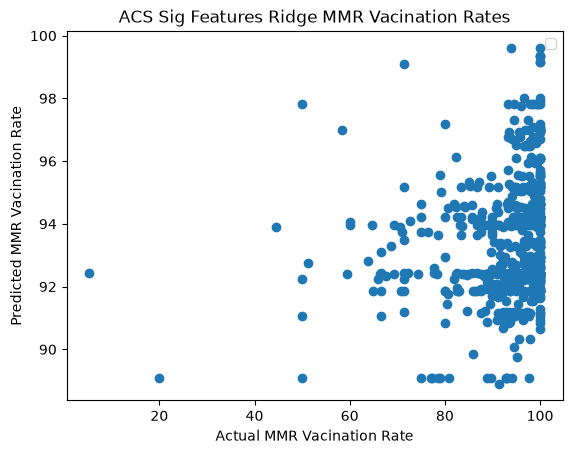

In [19]:
#plt.scatter(range(len(y_ridge_results['test_sig'])), y_ridge_results['test_sig'], label="Actual")
#plt.scatter(range(len(y_ridge_results['predict_sig'])), y_ridge_results['predict_sig'], label="Predicted", alpha=0.5)
plt.scatter(y_ridge_results['test_sig'], y_ridge_results['predict_sig'])
plt.legend()
plt.xlabel("Actual MMR Vacination Rate")
plt.ylabel("Predicted MMR Vacination Rate")
#plt.ylabel("MMR Vacination Rate")
plt.title("ACS Sig Features Ridge MMR Vacination Rates")
#plt.savefig('../plots/ridge_vac_rates_acs_sig_features.png', bbox_inches="tight")
#plt.savefig('../plots/ridge_vac_rates_acs_sig_features_actual_predict.png', bbox_inches="tight")

In [42]:
print(f"R2_og = {r2_ridge_dict['all']}, R2_sig = {r2_ridge_dict['sig']}")


R2_og = 0.03434244895768601, R2_sig = 0.03811095008777832


In [43]:
#plt.errorbar(all_ridge_percent_df["Predictor"], all_ridge_percent_df["Mean"], yerr=np.abs(all_ridge_percent_df["CI_Upper"]- all_ridge_percent_df["CI_Lower"]), fmt='o', ecolor="orange")
#plt.xlabel("Predictor")
#plt.xticks(fontsize=6, rotation=90)
#plt.ylabel("Mean")
#plt.grid()
#plt.title("Texas County Measles Vaccination ACS Predictors")


In [44]:
all_ridge_percent_sig = all_ridge_percent_df[all_ridge_percent_df['Coeff Signficance'] == 'Signficant']
all_ridge_percent_sig
#all_ridge_percent_sig.to_csv(f"../ridge_regression_fit_results/all_acs_percent_ridge_regression_fit_county_sig.csv")
#all_ridge_percent_sig.to_csv(f"../ridge_regression_fit_results/all_acs_percent_ridge_regression_fit_county_sig_normalize_01.csv")

,Predictor,Mean,CI_Lower,CI_Upper,Coeff Signficance
15,Percent_GED_or_alternative_credential,4.811151,1.184939,8.622604,Signficant
24,Percent_American_Indian_and_Alaska_Native_alone,3.919775,0.704686,7.048318,Signficant
25,Percent_Asian_alone,6.613587,2.200616,10.862622,Signficant
27,Percent_Native_Hawaiian_and_Other_Pacific_Isla...,-4.572116,-8.487943,-1.216078,Signficant
28,Percent_Some_Other_Race_alone,4.496496,0.413791,8.632381,Signficant
29,Percent_Two_or_More_Races,3.528188,1.903511,5.188384,Signficant
31,Percent_Two_or_More_Races_Two_races_including_...,3.072617,1.522756,4.561892,Signficant
32,Percent_White_alone,-8.218685,-11.068362,-5.631104,Signficant
53,Percent_45_49,-5.832133,-11.235328,-0.656831,Signficant
57,Percent_62_64,6.570020,1.041008,12.073650,Signficant


In [45]:
#plt.errorbar(all_ridge_percent_sig["Predictor"], all_ridge_percent_sig["Mean"], yerr=np.abs(all_ridge_percent_sig["CI_Upper"]- all_ridge_percent_sig["CI_Lower"]), fmt='o', ecolor="orange")
#plt.title("TX County Measles Vaccination Sig Predictors")
#plt.xlabel("Predictor")
#plt.xticks(fontsize=7, rotation=80)
#plt.ylabel("Mean")
#plt.grid()
#plt.savefig("../plots/tx_county_ridge_regression_acs_sig_predictors.png", bbox_inches="tight")

In [46]:
all_linear_percent_df, r2_linear_dict, y_linear_results = bootstrap_confidence_interval(1000, all_vac_set_no_gender_percent, model_type="Linear", drop_columns=['County'])
#all_linear_percent_df

In [47]:
y_linear_results['predict_og']

array([ 93.72449665,  93.52187838,  93.52187838,  93.35729582,
        93.85238022,  93.42740574,  89.30995997,  91.43208109,
        89.30995997,  90.7265323 ,  93.85311818,  93.52187838,
       101.83030825,  91.50964563,  93.60916254,  93.14878534,
        93.52187838,  93.72449665,  97.74368461,  93.52187838,
        96.79535613,  92.15252063,  92.06393361,  89.3642283 ,
        93.52187838,  90.7265323 ,  93.85238022,  96.86674069,
        95.10854925,  95.20175961,  93.52187838,  92.80578755,
        88.03525626,  94.01959042,  90.7265323 ,  92.06393361,
        93.85311818,  95.79541642,  91.23887771,  93.42740574,
        98.80074563,  91.10798895,  91.79374478,  89.30995997,
        91.21317712,  94.23472104,  93.52187838,  94.04500894,
        96.583735  ,  92.80578755,  89.30995997,  89.48792296,
        96.42185402,  95.83386947,  92.87903183,  93.42740574,
        93.52187838,  95.55162109,  93.72449665,  97.66489241,
        93.72449665,  93.52187838,  93.42740574,  94.01

In [48]:
print(f"R2_og = {r2_linear_dict['all']}, R2_sig = {r2_linear_dict['sig']}")

R2_og = 0.06564547299452439, R2_sig = 0.039026843000241174


C:\Users\19037\AppData\Local\Temp\ipykernel_10944\448387320.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, 'ACS Sig Features Linear MMR Vacination Rates')

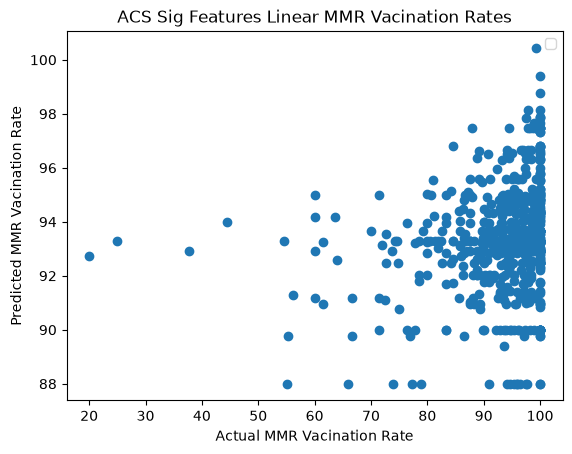

In [49]:
#plt.scatter(range(len(y_linear_results['test_sig'])), y_linear_results['test_sig'], label="Actual")
#plt.scatter(range(len(y_linear_results['predict_sig'])), y_linear_results['predict_sig'], label="Predicted", alpha=0.5)
plt.scatter(y_linear_results['test_sig'], y_linear_results['predict_sig'])
plt.legend()
plt.xlabel("Actual MMR Vacination Rate")
plt.ylabel("Predicted MMR Vacination Rate")
#plt.ylabel("MMR Vacination Rate")
plt.title("ACS Sig Features Linear MMR Vacination Rates")
#plt.savefig('../plots/linear_vac_rates_acs_sig_features.png', bbox_inches="tight")
#plt.savefig('../plots/linear_vac_rates_acs_sig_features_actual_predict.png', bbox_inches="tight")

In [50]:
#all_linear_percent_df.to_csv(f"../linear_regression_fit_results/all_acs_percent_linear_regression_fit_county_results_normalize_01.csv")

In [51]:
all_linear_percent_sig = all_linear_percent_df[all_linear_percent_df['Coeff Signficance'] == 'Signficant']
all_linear_percent_sig
#all_linear_percent_sig.to_csv(f"../linear_regression_fit_results/all_acs_percent_linear_regression_fit_county_sig_normalize_01.csv")

,Predictor,Mean,CI_Lower,CI_Upper,Coeff Signficance
24,Percent_American_Indian_and_Alaska_Native_alone,4.179647,0.468912,8.373524,Signficant
25,Percent_Asian_alone,5.107998,0.240313,10.030139,Signficant
27,Percent_Native_Hawaiian_and_Other_Pacific_Isla...,-3.926475,-7.783737,-0.180625,Signficant
29,Percent_Two_or_More_Races,3.567214,1.568950,5.456601,Signficant
31,Percent_Two_or_More_Races_Two_races_including_...,2.768512,0.862127,4.551802,Signficant
32,Percent_White_alone,-7.430502,-10.057352,-4.708289,Signficant
64,Estimate_Total_Income_in_the_past_12_months_at...,-21.923223,-38.607553,-4.998574,Signficant
65,Estimate_Total_Income_in_the_past_12_months_be...,17.646030,0.745850,34.277501,Signficant
